In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score

# dataset
X, y = make_regression(n_samples=100, n_features=2, noise=10)

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# model
model = LinearRegression()
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

R2 Score: 0.981397185597344
Slope: [37.78063216 42.41070644]
Intercept: -0.4876535097683079


In [2]:
from sklearn.linear_model import RidgeCV

model = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
model.fit(X_train, y_train)

print("Best alpha:", model.alpha_)

Best alpha: 1.0


In [3]:
from sklearn.linear_model import LassoCV

model = LassoCV(cv=5)
model.fit(X_train, y_train)

print("Selected features:", model.coef_)

Selected features: [37.72095233 42.37101838]


In [4]:
from sklearn.linear_model import BayesianRidge

model = BayesianRidge()
model.fit(X_train, y_train)

print(model.coef_)

[37.76100424 42.39546681]


Slope (w): 0.6
Intercept (b): 2.2
Predictions: [2.8 3.4 4.  4.6 5.2]


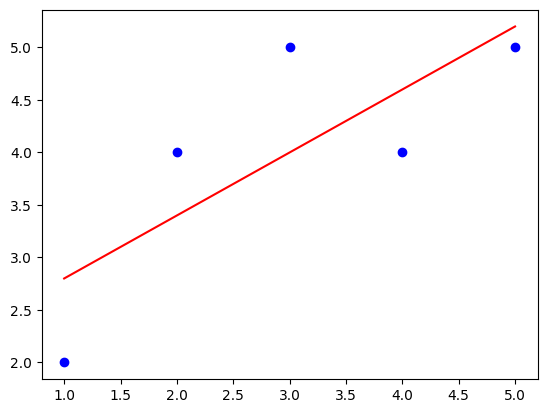

In [1]:
# Linear regression from scratch

import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

x_mean = np.mean(X)
y_mean = np.mean(y)
numerator = np.sum((X-x_mean)*(y-y_mean))
denominator = np.sum((X-x_mean)**2)
w = numerator/denominator
b = y_mean-w*x_mean

y_pred = w*X + b

print("Slope (w):", w)
print("Intercept (b):", b)
print("Predictions:", y_pred)

plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red')
plt.show()


Epoch 0: Loss = 17.2000
Epoch 100: Loss = 0.8099
Epoch 200: Loss = 0.6476
Epoch 300: Loss = 0.5651
Epoch 400: Loss = 0.5232
Epoch 500: Loss = 0.5020
Epoch 600: Loss = 0.4912
Epoch 700: Loss = 0.4857
Epoch 800: Loss = 0.4829
Epoch 900: Loss = 0.4815

Final Parameters:
Slope (w): 0.6176946148762643
Intercept (b): 2.136116825825789


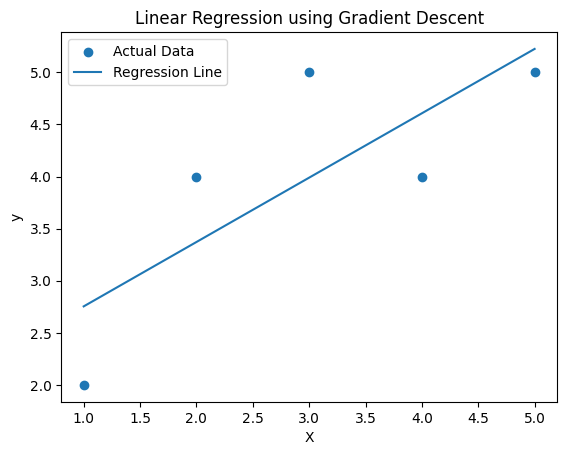

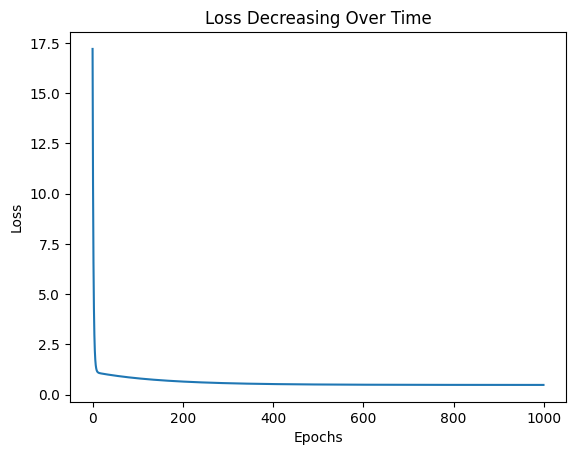

In [3]:
# using gradient descent

X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

w = 0
b = 0
learning_rate = 0.01
epochs = 1000
n = len(X)
losses = []

for i in range(epochs):
    y_pred = w * X + b
    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    if i % 100 == 0:
        print(f"Epoch {i}: Loss = {loss:.4f}")

print("\nFinal Parameters:")
print("Slope (w):", w)
print("Intercept (b):", b)

y_pred = w * X + b

plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, label="Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.show()

plt.plot(range(epochs), losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Decreasing Over Time")
plt.show()

